# CPWL spectral operator through the matrix sign map
Convergence of a decomposition-free CPWL operator, built from the Newton–Schulz msgn surrogate, to the exact operator read off a signed SVD. Plot 1: relative Frobenius error against the iteration count k, one curve per degree D. Plot 2: for one D, the operator's output spectrum at a few values of k against the input singular values and the exact target profile. A run stops once the error reaches `eps` (default: 10 machine epsilons) and holds the error and spectrum until `k_max`. Degree and step counts of plot 2 are picked in the plot cell, no rerun needed. Edit the config and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_operator import CPWLOperatorConfig, run_cpwl_convergence
%matplotlib inline

## Plot 1: error against iterations, several degrees D

In [3]:
cfg = CPWLOperatorConfig(
    m=64, n=64, rank=None, cond=1e3, sigma_max=1.0, spectrum="log",
    profile="spline", alpha=-0.3, beta=0.5, 
    gamma=0.5, a=0.3, mu=0.5, 
    knots=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],  # spline knot points
    vals=[0.1, 0.2, 0.9, 0.9, 0.4, 0.5, 0.2, 0.4, 0.4],         # spline values at knot points
    degrees=[1, 2, 3, 4],  # polynomial degrees to test
    k_max=50,     # steps (each internal sign call runs exactly k steps)
    eps=1e-12,     # a run stops once the operator error reaches this; None = 10 machine eps
    dtype=torch.float64, device="cuda", seed=0,
)
res = run_cpwl_convergence(cfg)

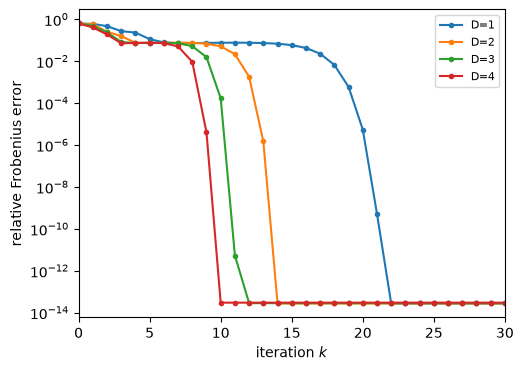

In [5]:
plots.plot_error_curves(
    res["error"], ylabel="relative Frobenius error",
    eps=cfg.eps,           # None = no markers or line
    show_first_hit=False,   # mark the first step with error <= eps
    show_eps_line=False,    # horizontal line at eps
    k_plot=30,           # last step shown (None = all)
);

## Plot 2: spectrum convergence, one degree D

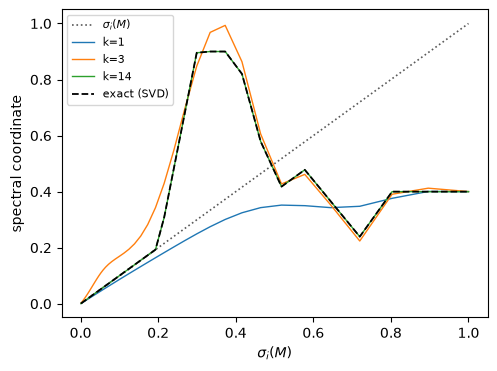

In [6]:
D_show = 2   # degree to draw (any of cfg.degrees)
plots.plot_spectrum(
    res["sigma"], res["target"], res["coords"][D_show],
    ks=[1,3, 14],   # step counts to draw (None = all, up to cfg.k_max)
    xaxis="sigma",     # "sigma" (values) or "index" (rank order)
    labels=None,       # legend text per k, e.g. {1: "one step"}; None = "k=..."
);

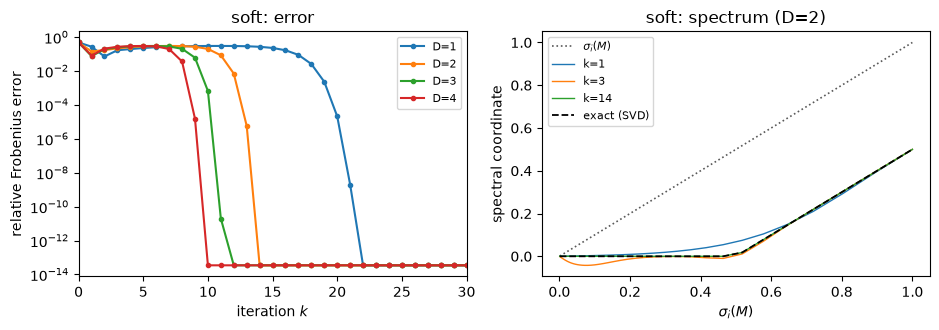

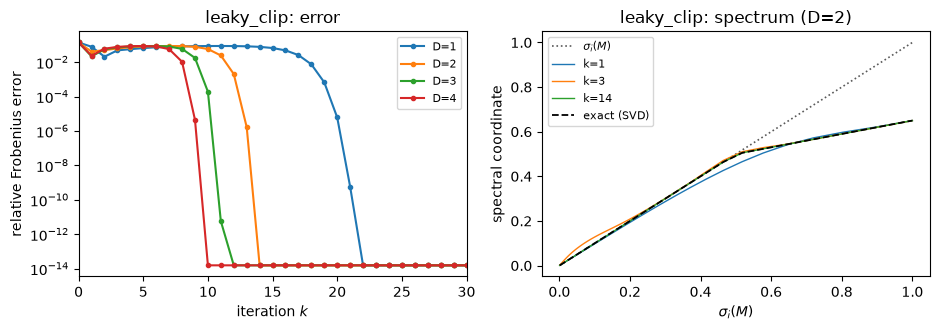

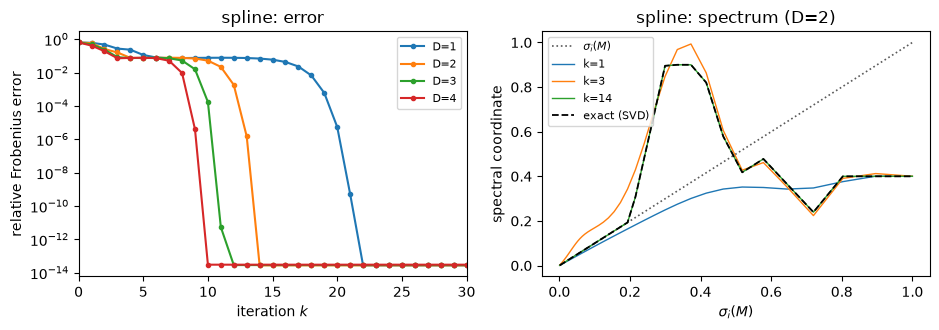

In [7]:
import os
from dataclasses import replace

os.makedirs("../figures", exist_ok=True)
for profile in ["soft", "leaky_clip", "spline"]:
    c = replace(cfg, profile=profile)
    r = run_cpwl_convergence(c)
    fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.4))
    plots.plot_error_curves(
        r["error"], ax=axs[0], ylabel="relative Frobenius error",
        eps=c.eps, show_first_hit=False, show_eps_line=False, k_plot=30,
    )
    plots.plot_spectrum(
        r["sigma"], r["target"], r["coords"][D_show], ax=axs[1],
        xaxis="sigma", ks=[1, 3, 14],
    )
    axs[0].set_title(f"{profile}: error")
    axs[1].set_title(f"{profile}: spectrum (D={D_show})")
    fig.tight_layout()
    fig.savefig(f"../figures/cpwl_{profile}_m{c.m}_n{c.n}.pdf", bbox_inches="tight")